# Biểu đồ của report đánh giá — AutoLabel 3D

Notebook này vẽ mọi biểu đồ của [REPORT.md](REPORT.md) từ số liệu trong `eval/results/` và hiện ngay bên dưới, không xuất
ra file ảnh. Chạy lại: mở notebook rồi **Run All** (cần `matplotlib`; không cần GPU hay dữ liệu nuScenes).

Mọi số đọc từ file JSON trong `eval/results`. Một vài số đo thời gian không có trong JSON (đo bằng lệnh profile, đo trên
máy ảo) được ghi thẳng trong ô tương ứng, kèm nguồn.

Màu: cam = cấu hình được chọn / sau tối ưu, xanh = phương án khác / trước, xám = mốc tham chiếu.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt

%matplotlib inline

# Tìm gốc repo (thư mục có eval/results) từ nơi mở notebook, để chạy được từ gốc repo lẫn từ eval/report
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "eval" / "results").is_dir())
RES = ROOT / "eval" / "results"

# Bảng màu: cam = cấu hình được chọn / sau tối ưu, xanh = phương án khác / trước, xám = mốc tham chiếu
ORANGE, BLUE, GRAY, INK, MUTED, GRID = "#C96A12", "#2E6FC0", "#9AA0A6", "#1F2328", "#5F6368", "#E6E6E6"
GREEN, RED = "#2E8B57", "#B23B3B"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10, "axes.edgecolor": "#BDBDBD", "axes.labelcolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100,
    "legend.frameon": False,
})

In [2]:
def load(rel: str):
    return json.loads((RES / rel).read_text(encoding="utf-8"))


def save(fig, name: str = ""):
    """Hiện biểu đồ ngay trong notebook (trước đây ghi ra eval/report/figures/*.png)."""
    fig.patch.set_facecolor("white")
    plt.show()
    plt.close(fig)


def grid(ax, axis="x"):
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)


NAMES3D = {
    "fcos3d": "FCOS3D (camera)", "pgd": "PGD (camera)", "ssn": "SSN", "pointpillars": "PointPillars",
    "centerpoint_pillar": "CenterPoint pillar", "centerpoint_voxel": "CenterPoint voxel",
    "centerpoint_voxel_track": "CP voxel + track", "fuse4": "Gộp 4 LiDAR", "ensemble": "Gộp 4 LiDAR + track (mặc định)",
    "ensemble6": "Gộp 4 LiDAR + 2 camera + track",
}
ORDER3D = list(NAMES3D)
# s/keyframe trên RTX 4050 (eval/results/det3d/*/run.json); ensemble = tổng 4 mô hình + gộp/track đo trên CPU (~0.085 s)
RUN = {m: load(f"det3d/{m}/run.json")["s_per_sample"] for m in ORDER3D[:6]}
LIDAR4 = sum(RUN[m] for m in ("pointpillars", "ssn", "centerpoint_pillar", "centerpoint_voxel"))
TIME3D = dict(RUN, centerpoint_voxel_track=RUN["centerpoint_voxel"] + 0.005, fuse4=LIDAR4 + 0.08,
              ensemble=LIDAR4 + 0.085, ensemble6=LIDAR4 + RUN["fcos3d"] + RUN["pgd"] + 0.1)


def color3d(m):
    return ORANGE if m == "ensemble" else (GRAY if m in ("fcos3d", "pgd") else BLUE)


# ---------------------------------------------------------------- 3D: mAP / NDS

## 1. Detector 3D: mAP và NDS

Mục 2 của REPORT.md.

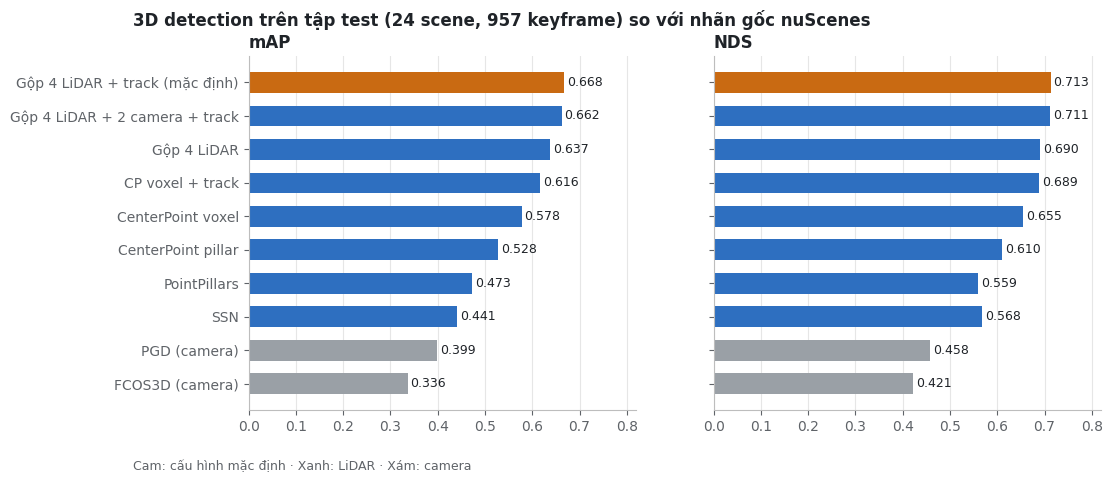

In [3]:
def fig_3d_models():
    d = load("det3d/heldout24.json")
    ms = sorted(ORDER3D, key=lambda m: d[m]["heldout"]["mAP"])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
    for ax, key, title in ((axes[0], "mAP", "mAP"), (axes[1], "NDS", "NDS")):
        vals = [d[m]["heldout"][key] for m in ms]
        ax.barh(range(len(ms)), vals, color=[color3d(m) for m in ms], height=0.62)
        for i, v in enumerate(vals):
            ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=9, color=INK)
        ax.set_xlim(0, 0.82)
        ax.set_title(title, loc="left")
        grid(ax)
    axes[0].set_yticks(range(len(ms)), [NAMES3D[m] for m in ms])
    fig.suptitle("3D detection trên tập test (24 scene, 957 keyframe) so với nhãn gốc nuScenes", x=0.02, ha="left",
                 fontsize=12, fontweight="bold", color=INK)
    fig.text(0.02, -0.02, "Cam: cấu hình mặc định · Xanh: LiDAR · Xám: camera", color=MUTED, fontsize=9)
    save(fig, "fig01_3d_map_nds.png")


fig_3d_models()

## 2. Detector 3D: đánh đổi tốc độ – độ chính xác

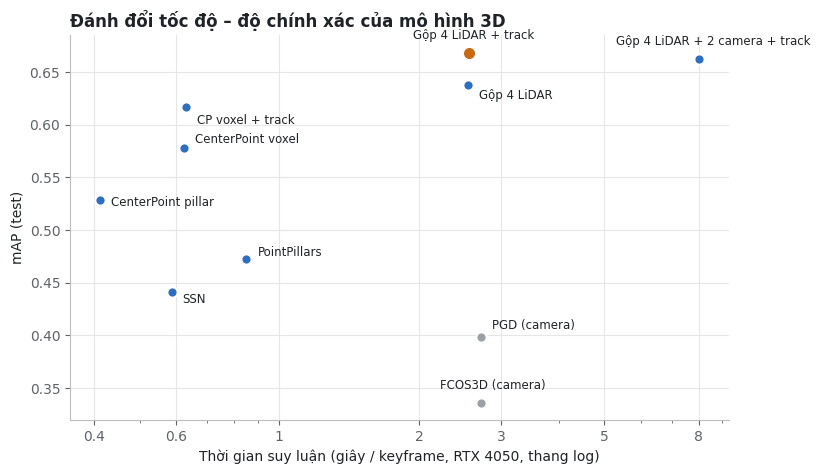

In [4]:
def fig_3d_speed():
    d = load("det3d/heldout24.json")
    fig, ax = plt.subplots(figsize=(8.5, 5))
    offs = {"centerpoint_voxel_track": (8, -12), "fuse4": (8, -10), "ensemble": (-40, 10), "ensemble6": (-60, 10),
            "centerpoint_voxel": (8, 4), "centerpoint_pillar": (8, -4), "ssn": (8, -8), "pointpillars": (8, 2),
            "fcos3d": (-30, 10), "pgd": (8, 6)}
    for m in ORDER3D:
        x, y = TIME3D[m], d[m]["heldout"]["mAP"]
        ax.scatter(x, y, s=90 if m == "ensemble" else 55, color=color3d(m), zorder=3, edgecolor="white", linewidth=1.5)
        ax.annotate(NAMES3D[m].replace(" (mặc định)", ""), (x, y), textcoords="offset points", xytext=offs[m],
                    fontsize=8.5, color=INK)
    ax.set_xscale("log")
    ax.set_xticks([0.4, 0.6, 1, 2, 3, 5, 8], ["0.4", "0.6", "1", "2", "3", "5", "8"])
    ax.set_xlabel("Thời gian suy luận (giây / keyframe, RTX 4050, thang log)")
    ax.set_ylabel("mAP (test)")
    ax.set_title("Đánh đổi tốc độ – độ chính xác của mô hình 3D", loc="left")
    grid(ax, "both")
    save(fig, "fig02_3d_speed_accuracy.png")


fig_3d_speed()

## 3. Detector 3D: precision / recall / F1

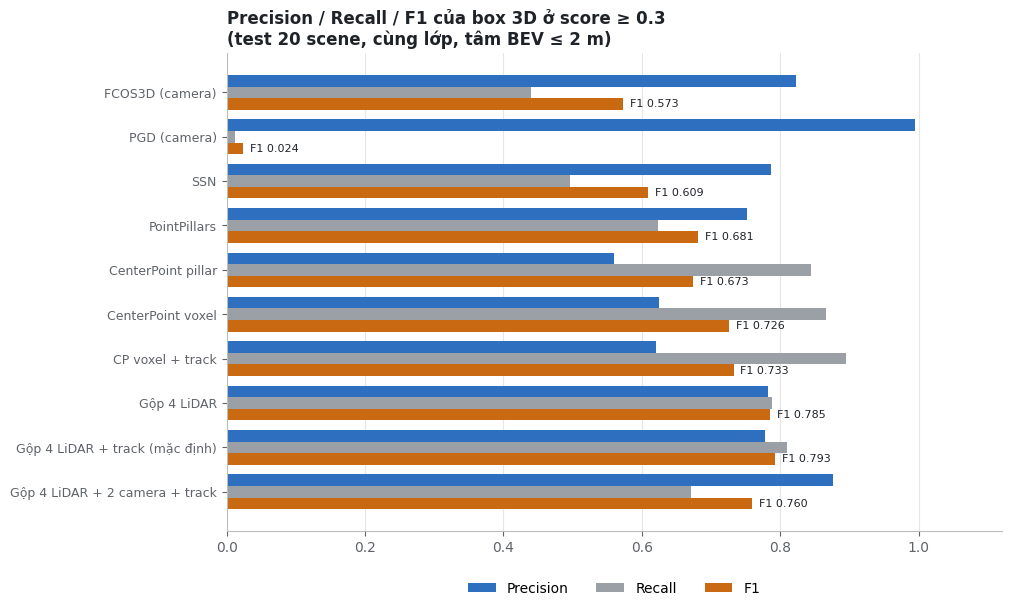

In [5]:
def fig_3d_pr():
    pr = load("det3d/pr_test20.json")["results"]
    ms = ORDER3D[::-1]
    fig, ax = plt.subplots(figsize=(10, 6.2))
    h = 0.26
    for k, (key, col, lab) in enumerate((("F1", ORANGE, "F1"), ("R", GRAY, "Recall"), ("P", BLUE, "Precision"))):
        vals = [pr[m]["0.3"][key] for m in ms]
        ax.barh([i + (k - 1) * h for i in range(len(ms))], vals, height=h, color=col, label=lab)
        if key == "F1":
            for i, v in enumerate(vals):
                ax.text(v + 0.01, i - h, f"F1 {v:.3f}", va="center", fontsize=8, color=INK)
    ax.set_yticks(range(len(ms)), [NAMES3D[m] for m in ms], fontsize=9)
    ax.set_xlim(0, 1.12)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))
    ax.set_title("Precision / Recall / F1 của box 3D ở score ≥ 0.3\n(test 20 scene, cùng lớp, tâm BEV ≤ 2 m)", loc="left")
    grid(ax)
    save(fig, "fig03_3d_precision_recall.png")


fig_3d_pr()

## 4. Detector 3D: AP từng lớp

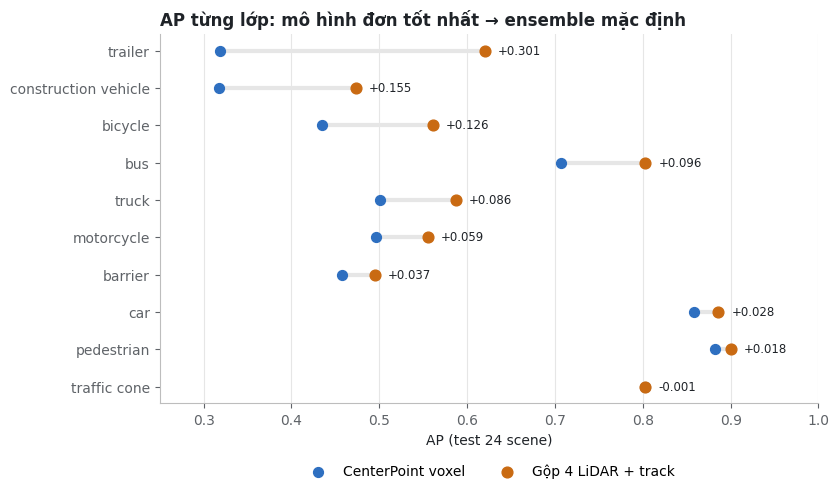

In [6]:
def fig_3d_classes():
    d = load("det3d/heldout24.json")
    a, b = d["centerpoint_voxel"]["heldout"]["ap"], d["ensemble"]["heldout"]["ap"]
    cls = sorted(a, key=lambda c: b[c] - a[c])
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for i, c in enumerate(cls):
        ax.plot([a[c], b[c]], [i, i], color=GRID, linewidth=3, zorder=1)
        ax.scatter(a[c], i, color=BLUE, s=50, zorder=2, label="CenterPoint voxel" if i == 0 else None)
        ax.scatter(b[c], i, color=ORANGE, s=60, zorder=3, label="Gộp 4 LiDAR + track" if i == 0 else None)
        ax.text(max(a[c], b[c]) + 0.015, i, f"{b[c] - a[c]:+.3f}", va="center", fontsize=8.5, color=INK)
    ax.set_yticks(range(len(cls)), [c.replace("_", " ") for c in cls])
    ax.set_xlim(0.25, 1.0)
    ax.set_xlabel("AP (test 24 scene)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
    ax.set_title("AP từng lớp: mô hình đơn tốt nhất → ensemble mặc định", loc="left")
    grid(ax)
    save(fig, "fig04_3d_ap_per_class.png")


fig_3d_classes()

## 5. Detector 2D: chọn mô hình và fine-tune

Mục 3 của REPORT.md.

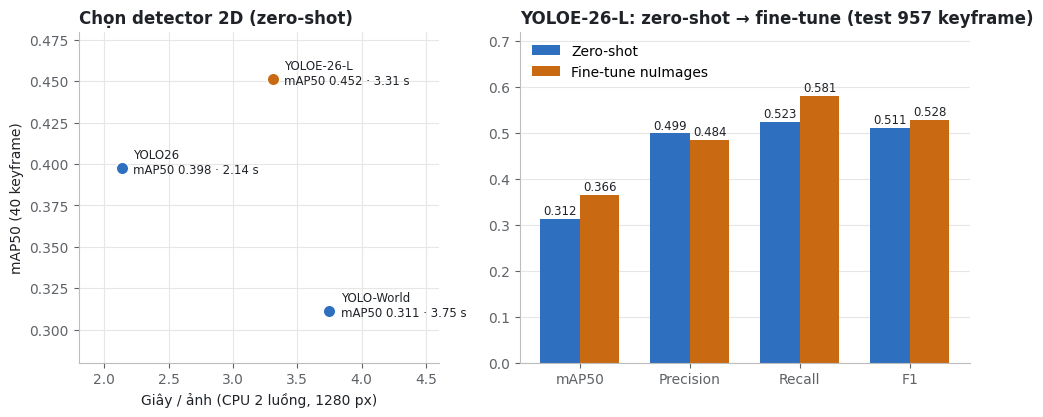

In [7]:
# ---------------------------------------------------------------- 2D detector


def fig_2d_detectors():
    sp = load("compare/speed.json")["detectors"]
    m40 = {k: load(f"compare/{k}/autolabel2d_eval.json")["map50"]["map"] for k in ("yolo_world", "yolo26", "yoloe")}
    ft = load("det2d_finetune.json")
    zs, fn = ft["yoloe-26l-seg.pt@1280:heldout"], ft["yoloe-26l-nuimages-lp-1280.pt@1280:heldout"]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), gridspec_kw={"width_ratios": [1, 1.25]})
    ax = axes[0]
    names = {"yolo_world": "YOLO-World", "yolo26": "YOLO26", "yoloe": "YOLOE-26-L"}
    for k in m40:
        ax.scatter(sp[k]["mean_s"], m40[k], s=80, color=ORANGE if k == "yoloe" else BLUE, zorder=3, edgecolor="white")
        ax.annotate(f"{names[k]}\nmAP50 {m40[k]:.3f} · {sp[k]['mean_s']:.2f} s", (sp[k]["mean_s"], m40[k]),
                    textcoords="offset points", xytext=(8, -4), fontsize=8.5, color=INK)
    ax.set_xlim(1.8, 4.6)
    ax.set_ylim(0.28, 0.48)
    ax.set_xlabel("Giây / ảnh (CPU 2 luồng, 1280 px)")
    ax.set_ylabel("mAP50 (40 keyframe)")
    ax.set_title("Chọn detector 2D (zero-shot)", loc="left")
    grid(ax, "both")
    ax = axes[1]
    keys = [("mAP50", "mAP50"), ("P", "Precision"), ("R", "Recall"), ("F1", "F1")]
    w = 0.36
    for j, (res, col, lab) in enumerate(((zs, BLUE, "Zero-shot"), (fn, ORANGE, "Fine-tune nuImages"))):
        vals = [res[k] for k, _ in keys]
        ax.bar([i + (j - 0.5) * w for i in range(len(keys))], vals, width=w, color=col, label=lab)
        for i, v in enumerate(vals):
            ax.text(i + (j - 0.5) * w, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5, color=INK)
    ax.set_xticks(range(len(keys)), [lab for _, lab in keys])
    ax.set_ylim(0, 0.72)
    ax.legend(loc="upper left")
    ax.set_title("YOLOE-26-L: zero-shot → fine-tune (test 957 keyframe)", loc="left")
    grid(ax, "y")
    save(fig, "fig05_2d_detector.png")


fig_2d_detectors()

## 6. Detector 2D: AP50 từng lớp

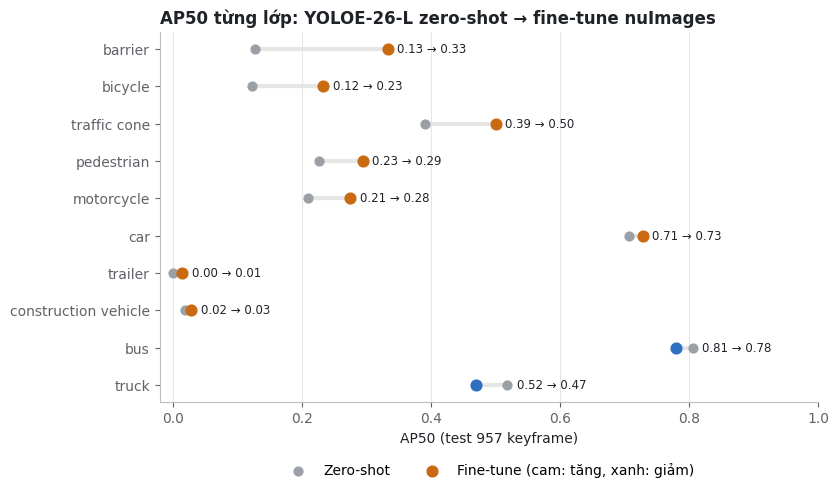

In [8]:
def fig_2d_classes():
    ft = load("det2d_finetune.json")
    a, b = ft["yoloe-26l-seg.pt@1280:heldout"]["ap"], ft["yoloe-26l-nuimages-lp-1280.pt@1280:heldout"]["ap"]
    cls = sorted(a, key=lambda c: b[c] - a[c])
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for i, c in enumerate(cls):
        up = b[c] >= a[c]
        ax.plot([a[c], b[c]], [i, i], color=GRID, linewidth=3, zorder=1)
        ax.scatter(a[c], i, color=GRAY, s=40, zorder=2, label="Zero-shot" if i == 0 else None)
        ax.scatter(b[c], i, color=ORANGE if up else BLUE, s=60, zorder=3,
                   label="Fine-tune (cam: tăng, xanh: giảm)" if i == len(cls) - 1 else None)
        ax.text(max(a[c], b[c]) + 0.015, i, f"{a[c]:.2f} → {b[c]:.2f}", va="center", fontsize=8.5, color=INK)
    ax.set_yticks(range(len(cls)), [c.replace("_", " ") for c in cls])
    ax.set_xlim(-0.02, 1.0)
    ax.set_xlabel("AP50 (test 957 keyframe)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
    ax.set_title("AP50 từng lớp: YOLOE-26-L zero-shot → fine-tune nuImages", loc="left")
    grid(ax)
    save(fig, "fig06_2d_ap_per_class.png")


fig_2d_classes()

## 7. Lan truyền nhãn 2D: optical flow × ByteTrack × OC-SORT

Mục 5 của REPORT.md (đợt đo đầu, detector zero-shot). Bảng mới hơn có BoT-SORT và DAM4SAM: `eval/results/tracking.md`.

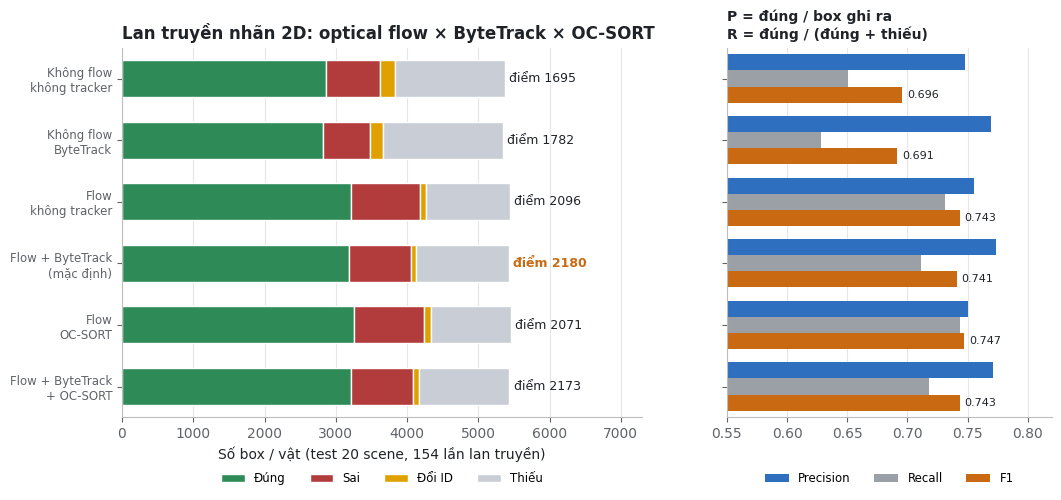

In [9]:
# ---------------------------------------------------------------- lan truyền 2D
TRK = [("noflow+single", "Không flow\nkhông tracker"), ("noflow", "Không flow\nByteTrack"),
       ("single", "Flow\nkhông tracker"), ("base", "Flow + ByteTrack\n(mặc định)"), ("ocr+single", "Flow\nOC-SORT"),
       ("ocr", "Flow + ByteTrack\n+ OC-SORT")]


def fig_tracker():
    t = load("tracker_test20.json")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.6, 1]})
    ax = axes[0]
    parts = [("correct_emit", GREEN, "Đúng"), ("wrong_emit", RED, "Sai"), ("id_switch_emit", "#E0A100", "Đổi ID"),
             ("missing_emit", "#C9CED6", "Thiếu")]
    for i, (k, _) in enumerate(TRK):
        left = 0
        for key, col, lab in parts:
            v = t[k][key]
            ax.barh(i, v, left=left, color=col, height=0.6, label=lab if i == 0 else None, edgecolor="white", linewidth=1)
            left += v
        score = t[k]["correct_emit"] - t[k]["wrong_emit"] - 2 * t[k]["id_switch_emit"]
        ax.text(left + 60, i, f"điểm {score}", va="center", fontsize=9, color=ORANGE if k == "base" else INK,
                fontweight="bold" if k == "base" else "normal")
    ax.set_yticks(range(len(TRK)), [lab for _, lab in TRK], fontsize=8.5)
    ax.set_ylim(len(TRK) - 0.5, -0.5)
    ax.set_xlim(0, 7300)
    ax.set_xlabel("Số box / vật (test 20 scene, 154 lần lan truyền)")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=8.5)
    ax.set_title("Lan truyền nhãn 2D: optical flow × ByteTrack × OC-SORT", loc="left")
    grid(ax)
    ax = axes[1]
    h = 0.26
    for j, (lab, col) in enumerate((("Precision", BLUE), ("Recall", GRAY), ("F1", ORANGE))):
        vals = []
        for k, _ in TRK:
            c, out, miss = t[k]["correct_emit"], t[k]["outputs_emit"], t[k]["missing_emit"]
            p, r = c / out, c / (c + miss)
            vals.append([p, r, 2 * p * r / (p + r)][j])
        ax.barh([i + (j - 1) * h for i in range(len(TRK))], vals, height=h, color=col, label=lab)
        if lab == "F1":
            for i, v in enumerate(vals):
                ax.text(v + 0.004, i + h, f"{v:.3f}", va="center", fontsize=8, color=INK)
    ax.set_yticks(range(len(TRK)), [""] * len(TRK))
    ax.set_ylim(len(TRK) - 0.5, -0.5)
    ax.set_xlim(0.55, 0.82)
    ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=8.5)
    ax.set_title("P = đúng / box ghi ra\nR = đúng / (đúng + thiếu)", loc="left", fontsize=10)
    grid(ax)
    save(fig, "fig07_2d_tracker.png")


fig_tracker()

## 8. Lan truyền nhãn 3D

Mục 6 của REPORT.md.

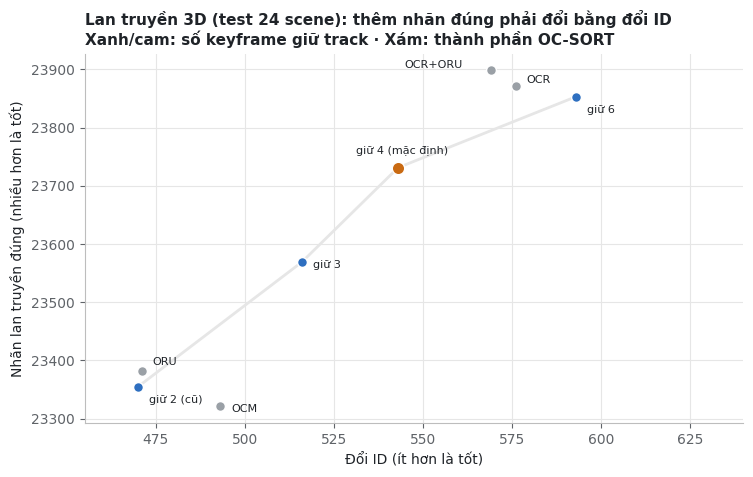

In [10]:
# ---------------------------------------------------------------- lan truyền 3D


def fig_prop3d():
    o = load("ocsort.json")["3d"]["test"]
    pts = [("base", "giữ 2 (cũ)", BLUE), ("base lost3", "giữ 3", BLUE), ("base lost4", "giữ 4 (mặc định)", ORANGE),
           ("base lost6", "giữ 6", BLUE), ("ocr", "OCR", GRAY), ("ocr+oru", "OCR+ORU", GRAY),
           ("oru", "ORU", GRAY), ("ocm", "OCM", GRAY)]
    offs = {"base": (8, -12), "base lost3": (8, -4), "base lost4": (-30, 10), "base lost6": (8, -12), "ocr": (8, 2),
            "ocr+oru": (-62, 2), "oru": (8, 4), "ocm": (8, -4)}
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    seq = ["base", "base lost3", "base lost4", "base lost6"]
    ax.plot([o[k]["id_switch"] for k in seq], [o[k]["correct"] for k in seq], color=GRID, linewidth=2, zorder=1)
    for k, lab, col in pts:
        ax.scatter(o[k]["id_switch"], o[k]["correct"], s=80 if col == ORANGE else 50, color=col, zorder=3,
                   edgecolor="white")
        ax.annotate(lab, (o[k]["id_switch"], o[k]["correct"]),
                    textcoords="offset points", xytext=offs[k], fontsize=8, color=INK)
    ax.set_xlabel("Đổi ID (ít hơn là tốt)")
    ax.set_ylabel("Nhãn lan truyền đúng (nhiều hơn là tốt)")
    ax.set_xlim(455, 640)
    ax.set_title("Lan truyền 3D (test 24 scene): thêm nhãn đúng phải đổi bằng đổi ID\nXanh/cam: số keyframe giữ track · Xám: thành phần OC-SORT", loc="left", fontsize=11)
    grid(ax, "both")
    save(fig, "fig08_3d_propagation.png")


fig_prop3d()

## 9. Lịch sử tối ưu

Mục 7 của REPORT.md.

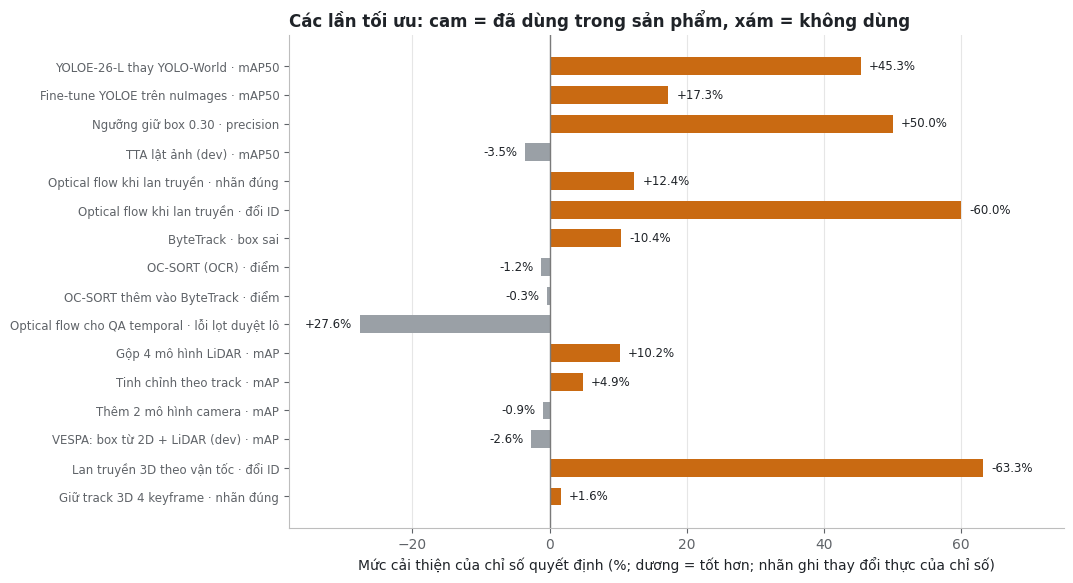

In [11]:
# ---------------------------------------------------------------- lịch sử tối ưu
# (tên, chỉ số, trước, sau, cao hơn là tốt?, có dùng) — số từ eval/results/bang-so-sanh.md
OPT = [
    ("YOLOE-26-L thay YOLO-World", "mAP50", 0.311, 0.452, True, True),
    ("Fine-tune YOLOE trên nuImages", "mAP50", 0.312, 0.366, True, True),
    ("Ngưỡng giữ box 0.30", "precision", 0.34, 0.51, True, True),
    ("TTA lật ảnh (dev)", "mAP50", 0.395, 0.381, True, False),
    ("Optical flow khi lan truyền", "nhãn đúng", 2866, 3220, True, True),
    ("Optical flow khi lan truyền", "đổi ID", 205, 82, False, True),
    ("ByteTrack", "box sai", 960, 860, False, True),
    ("OC-SORT (OCR)", "điểm", 2096, 2071, True, False),
    ("OC-SORT thêm vào ByteTrack", "điểm", 2180, 2173, True, False),
    ("Optical flow cho QA temporal", "lỗi lọt duyệt lô", 1632, 2082, False, False),
    ("Gộp 4 mô hình LiDAR", "mAP", 0.578, 0.637, True, True),
    ("Tinh chỉnh theo track", "mAP", 0.637, 0.668, True, True),
    ("Thêm 2 mô hình camera", "mAP", 0.668, 0.662, True, False),
    ("VESPA: box từ 2D + LiDAR (dev)", "mAP", 0.644, 0.627, True, False),
    ("Lan truyền 3D theo vận tốc", "đổi ID", 98, 36, False, True),
    ("Giữ track 3D 4 keyframe", "nhãn đúng", 23355, 23731, True, True),
]


def fig_optim():
    fig, ax = plt.subplots(figsize=(10, 6.4))
    rows = []
    for name, metric, a, b, higher, used in OPT:
        change = (b - a) / a * 100
        better = change if higher else -change
        rows.append((f"{name} · {metric}", better, change, used))
    for i, (lab, better, change, used) in enumerate(rows):
        ax.barh(i, better, color=ORANGE if used else GRAY, height=0.62)
        ax.text(better + (1.2 if better >= 0 else -1.2), i, f"{change:+.1f}%", va="center",
                ha="left" if better >= 0 else "right", fontsize=8.5, color=INK)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows], fontsize=8.5)
    ax.invert_yaxis()
    ax.axvline(0, color="#7A7A7A", linewidth=1)
    ax.set_xlim(-38, 75)
    ax.set_xlabel("Mức cải thiện của chỉ số quyết định (%; dương = tốt hơn; nhãn ghi thay đổi thực của chỉ số)")
    ax.set_title("Các lần tối ưu: cam = đã dùng trong sản phẩm, xám = không dùng", loc="left")
    grid(ax)
    save(fig, "fig09_optimization_history.png")


fig_optim()

## 10. QA Agent

Mục 4 của REPORT.md.

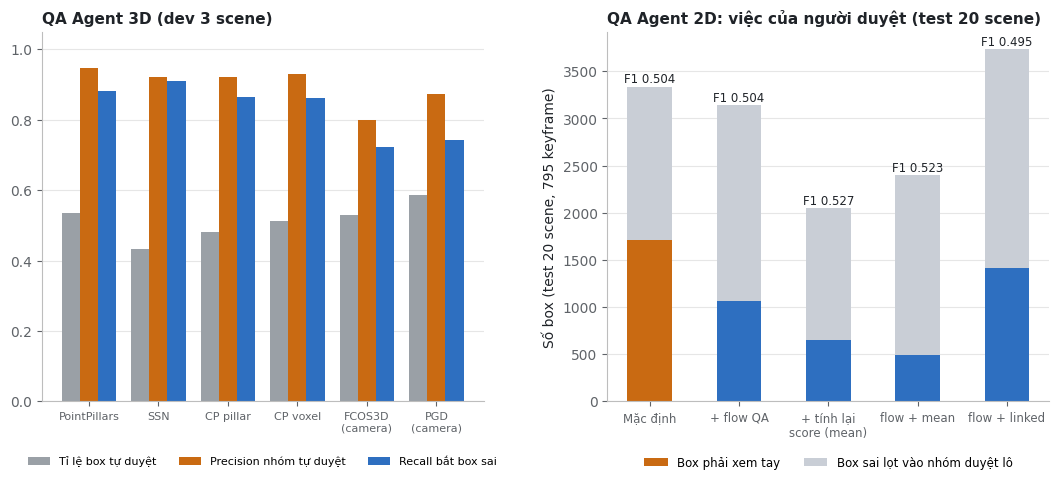

In [12]:
# ---------------------------------------------------------------- QA Agent


def fig_qa():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    fig.subplots_adjust(wspace=0.28)
    ax = axes[0]
    ms = ["pointpillars", "ssn", "centerpoint_pillar", "centerpoint_voxel", "fcos3d", "pgd"]
    v = {m: load(f"det3d/{m}/verify_eval.json") for m in ms}
    w = 0.26
    for j, (key, col, lab) in enumerate((("auto_share", GRAY, "Tỉ lệ box tự duyệt"),
                                         ("auto_precision", ORANGE, "Precision nhóm tự duyệt"),
                                         ("error_recall", BLUE, "Recall bắt box sai"))):
        ax.bar([i + (j - 1) * w for i in range(len(ms))], [v[m][key] for m in ms], width=w, color=col, label=lab)
    ax.set_xticks(range(len(ms)), [NAMES3D[m].replace(" (camera)", "\n(camera)").replace("CenterPoint ", "CP ")
                                   for m in ms], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    ax.set_ylim(0, 1.05)
    ax.set_title("QA Agent 3D (dev 3 scene)", loc="left", fontsize=11)
    grid(ax, "y")
    ax = axes[1]
    g = load("temporal/gpu_heldout20.json")["variants"]
    names = {"base": "Mặc định", "flow": "+ flow QA", "mean": "+ tính lại\nscore (mean)", "flow+mean": "flow + mean",
             "flow+linked": "flow + linked"}
    ks = list(names)
    review = [g[k]["objects"] * (1 - g[k]["low_risk_share"]) for k in ks]
    slip = [g[k]["objects"] * g[k]["low_risk_share"] * g[k]["low_risk_error_rate"] for k in ks]
    ax.bar(range(len(ks)), review, color=[ORANGE if k == "base" else BLUE for k in ks], width=0.5,
           label="Box phải xem tay")
    ax.bar(range(len(ks)), slip, bottom=review, color="#C9CED6", width=0.5, label="Box sai lọt vào nhóm duyệt lô")
    for i, k in enumerate(ks):
        ax.text(i, review[i] + slip[i] + 40, f"F1 {g[k]['f1']:.3f}", ha="center", fontsize=8.5, color=INK)
    ax.set_xticks(range(len(ks)), [names[k] for k in ks], fontsize=8.5)
    ax.set_ylabel("Số box (test 20 scene, 795 keyframe)")
    ax.legend(fontsize=8.5, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    ax.set_title("QA Agent 2D: việc của người duyệt (test 20 scene)", loc="left", fontsize=11)
    grid(ax, "y")
    save(fig, "fig10_qa_agent.png")


fig_qa()

## 11. Thời gian suy luận

Mục 8 của REPORT.md.

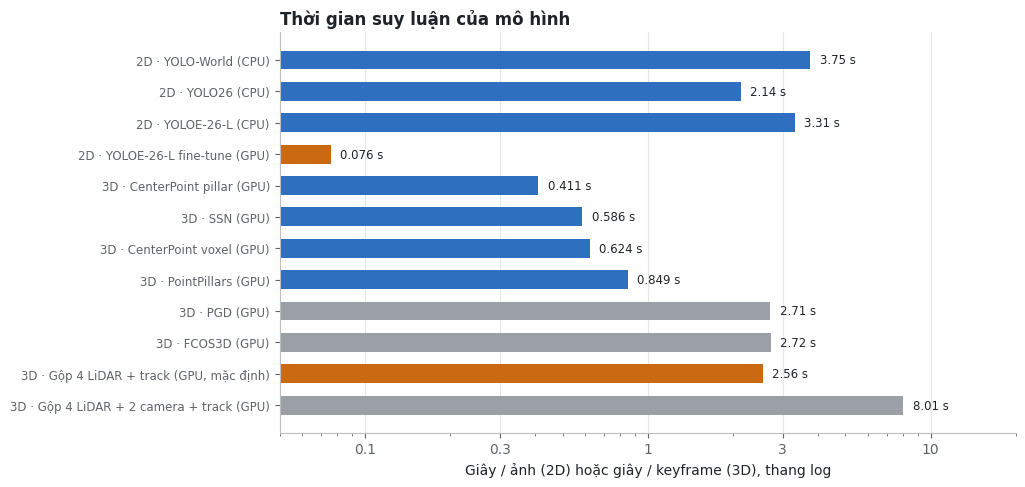

In [13]:
# ---------------------------------------------------------------- thời gian


def fig_time():
    sp = load("compare/speed.json")["detectors"]
    rows = [
        ("2D · YOLO-World (CPU)", sp["yolo_world"]["mean_s"], BLUE),
        ("2D · YOLO26 (CPU)", sp["yolo26"]["mean_s"], BLUE),
        ("2D · YOLOE-26-L (CPU)", sp["yoloe"]["mean_s"], BLUE),
        ("2D · YOLOE-26-L fine-tune (GPU)", 72.7 / 957, ORANGE),
        ("3D · CenterPoint pillar (GPU)", RUN["centerpoint_pillar"], BLUE),
        ("3D · SSN (GPU)", RUN["ssn"], BLUE),
        ("3D · CenterPoint voxel (GPU)", RUN["centerpoint_voxel"], BLUE),
        ("3D · PointPillars (GPU)", RUN["pointpillars"], BLUE),
        ("3D · PGD (GPU)", RUN["pgd"], GRAY),
        ("3D · FCOS3D (GPU)", RUN["fcos3d"], GRAY),
        ("3D · Gộp 4 LiDAR + track (GPU, mặc định)", TIME3D["ensemble"], ORANGE),
        ("3D · Gộp 4 LiDAR + 2 camera + track (GPU)", TIME3D["ensemble6"], GRAY),
    ]
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    for i, (lab, v, col) in enumerate(rows):
        ax.barh(i, v, color=col, height=0.6)
        ax.text(v * 1.08, i, f"{v:.3f} s" if v < 1 else f"{v:.2f} s", va="center", fontsize=8.5, color=INK)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_xlim(0.05, 20)
    ax.set_xticks([0.1, 0.3, 1, 3, 10], ["0.1", "0.3", "1", "3", "10"])
    ax.set_xlabel("Giây / ảnh (2D) hoặc giây / keyframe (3D), thang log")
    ax.set_title("Thời gian suy luận của mô hình", loc="left")
    grid(ax)
    save(fig, "fig11_inference_time.png")


fig_time()